In [1]:
# ============================================================
# Task 2: Fashion-MNIST Classification Project
# Step 1: Test basic Python libraries
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Basic libraries work successfully.")

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
NumPy version: 2.3.5
Pandas version: 2.3.3
Basic libraries work successfully.


In [2]:
# ============================================================
# Step 2: Test TensorFlow installation
# ============================================================

try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    print("TensorFlow imported successfully.")
except ImportError as e:
    print("TensorFlow is not installed yet.")
    print(e)

TensorFlow version: 2.21.0
TensorFlow imported successfully.


In [3]:
# ============================================================
# Step 3: Import all required project libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    accuracy_score
)

print("All project libraries imported successfully.")

All project libraries imported successfully.


In [4]:
# ============================================================
# Step 4: Create a folder to save result figures and tables
# ============================================================

results_dir = "results"

if not os.path.exists(results_dir):
    os.makedirs(results_dir)

print(f"Results folder ready: {results_dir}")

Results folder ready: results


In [5]:
# ============================================================
# Step 5: Load the Fashion-MNIST dataset
# ============================================================

# Fashion-MNIST is already included in TensorFlow/Keras
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Class names according to Fashion-MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10


In [6]:
# ============================================================
# Step 6: Create a dataset summary table
# ============================================================

dataset_summary = pd.DataFrame({
    "Dataset part": ["Training set", "Test set", "Total"],
    "Number of images": [x_train.shape[0], x_test.shape[0], x_train.shape[0] + x_test.shape[0]],
    "Image size": ["28 x 28 pixels", "28 x 28 pixels", "28 x 28 pixels"],
    "Color format": ["Grayscale", "Grayscale", "Grayscale"],
    "Number of classes": [len(class_names), len(class_names), len(class_names)]
})

dataset_summary

,Dataset part,Number of images,Image size,Color format,Number of classes
0,Training set,60000,28 x 28 pixels,Grayscale,10
1,Test set,10000,28 x 28 pixels,Grayscale,10
2,Total,70000,28 x 28 pixels,Grayscale,10


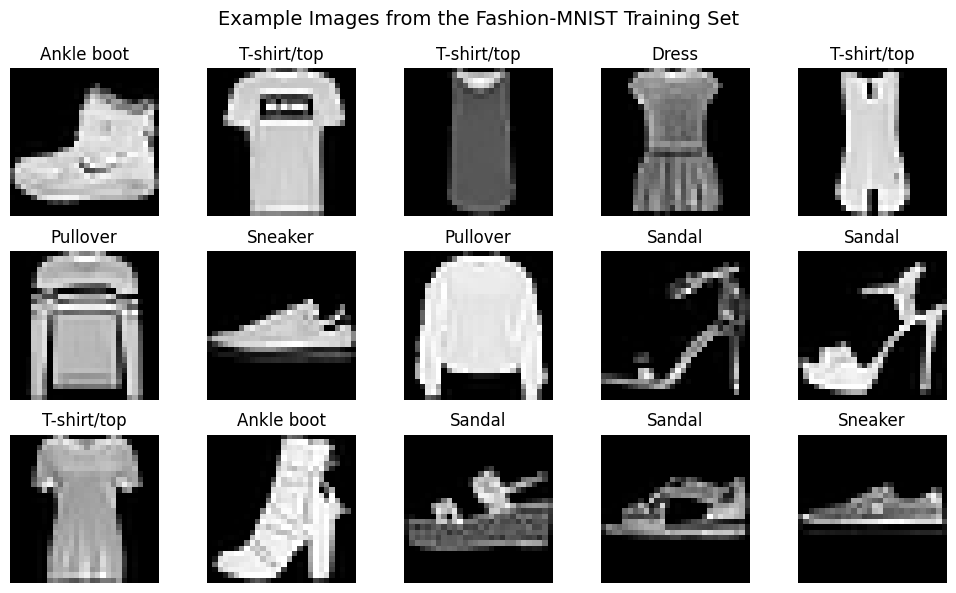

In [7]:
# ============================================================
# Step 7: Visualize example images from Fashion-MNIST
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Example Images from the Fashion-MNIST Training Set", fontsize=14)
plt.tight_layout()

# Save figure for report/GitHub
plt.savefig(os.path.join(results_dir, "fashion_mnist_examples.png"), dpi=300, bbox_inches="tight")

plt.show()

In [8]:
# ============================================================
# Step 8: Preprocess the data for CNN and Random Forest
# ============================================================

# Normalize pixel values from 0-255 to 0-1
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# CNN input: reshape to include the channel dimension
# Fashion-MNIST images are grayscale, so the channel number is 1
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding for CNN
y_train_cnn = to_categorical(y_train, num_classes=10)
y_test_cnn = to_categorical(y_test, num_classes=10)

# Random Forest input: flatten each 28x28 image into 784 pixel features
x_train_rf = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_rf = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("CNN training input shape:", x_train_cnn.shape)
print("CNN test input shape:", x_test_cnn.shape)
print("CNN training labels shape:", y_train_cnn.shape)
print("CNN test labels shape:", y_test_cnn.shape)

print("Random Forest training input shape:", x_train_rf.shape)
print("Random Forest test input shape:", x_test_rf.shape)

CNN training input shape: (60000, 28, 28, 1)
CNN test input shape: (10000, 28, 28, 1)
CNN training labels shape: (60000, 10)
CNN test labels shape: (10000, 10)
Random Forest training input shape: (60000, 784)
Random Forest test input shape: (10000, 784)


In [9]:
# ============================================================
# Step 9: Build the Convolutional Neural Network (CNN)
# ============================================================

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/opt/anaconda3/envs/fashionmnist/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# Step 10: Train the CNN model and measure training time
# ============================================================

cnn_start_time = time.time()

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

cnn_training_time = time.time() - cnn_start_time

print(f"CNN training time: {cnn_training_time:.2f} seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7797 - loss: 0.6124 - val_accuracy: 0.8550 - val_loss: 0.3888
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8608 - loss: 0.3884 - val_accuracy: 0.8753 - val_loss: 0.3358
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8788 - loss: 0.3352 - val_accuracy: 0.8780 - val_loss: 0.3229
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8889 - loss: 0.3026 - val_accuracy: 0.9005 - val_loss: 0.2773
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8986 - loss: 0.2787 - val_accuracy: 0.9045 - val_loss: 0.2679
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9042 - loss: 0.2607 - val_accuracy: 0.9015 - val_loss: 0.2629
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9094 - loss: 0.2449 - val_accuracy: 0.9033 - val_loss: 0.2537
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9153 - loss: 0.2332 - val_ac

In [11]:
# ============================================================
# Step 11: Evaluate CNN on training and test sets
# ============================================================

cnn_train_loss, cnn_train_accuracy = cnn_model.evaluate(
    x_train_cnn, y_train_cnn, verbose=0
)

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test_cnn, y_test_cnn, verbose=0
)

print(f"CNN training accuracy: {cnn_train_accuracy:.4f}")
print(f"CNN training loss: {cnn_train_loss:.4f}")

print(f"CNN test accuracy: {cnn_test_accuracy:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")

CNN training accuracy: 0.9357
CNN training loss: 0.1732
CNN test accuracy: 0.9066
CNN test loss: 0.2537


In [12]:
# ============================================================
# Step 12: Generate CNN predictions
# ============================================================

# Predicted probabilities
cnn_train_pred_probs = cnn_model.predict(x_train_cnn, verbose=0)
cnn_test_pred_probs = cnn_model.predict(x_test_cnn, verbose=0)

# Convert probabilities to class labels
cnn_train_pred = np.argmax(cnn_train_pred_probs, axis=1)
cnn_test_pred = np.argmax(cnn_test_pred_probs, axis=1)

print("CNN predictions generated successfully.")
print("Example predicted labels:", cnn_test_pred[:10])
print("Example true labels:", y_test[:10])

CNN predictions generated successfully.
Example predicted labels: [9 2 1 1 6 1 4 6 5 7]
Example true labels: [9 2 1 1 6 1 4 6 5 7]


In [13]:
# ============================================================
# Step 13: Create CNN confusion matrices for train and test sets
# ============================================================

cnn_train_cm = confusion_matrix(y_train, cnn_train_pred)
cnn_test_cm = confusion_matrix(y_test, cnn_test_pred)

print("CNN training confusion matrix shape:", cnn_train_cm.shape)
print("CNN test confusion matrix shape:", cnn_test_cm.shape)

CNN training confusion matrix shape: (10, 10)
CNN test confusion matrix shape: (10, 10)


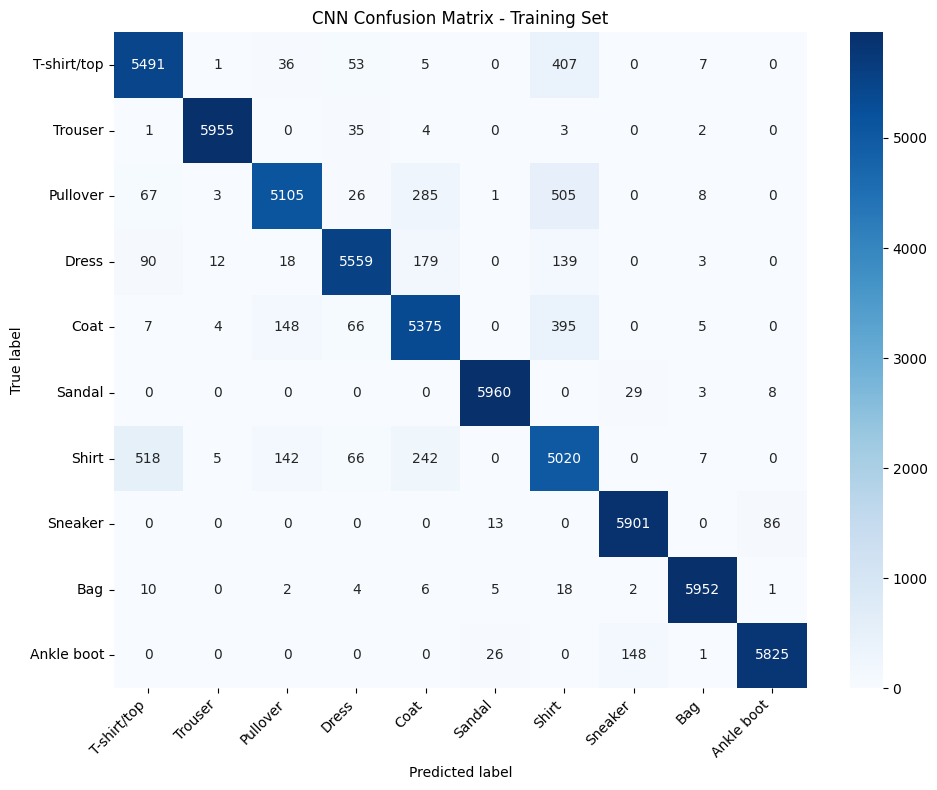

Saved figure: results/cnn_train_confusion_matrix.png


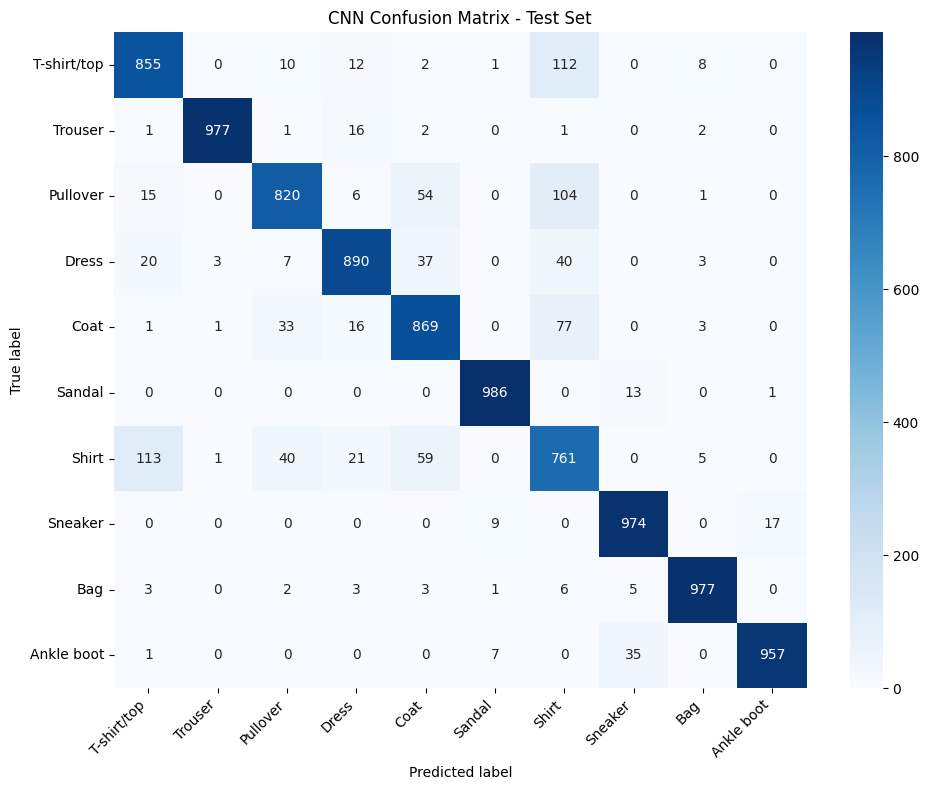

Saved figure: results/cnn_test_confusion_matrix.png


In [14]:
# ============================================================
# Step 14: Plot and save CNN confusion matrices
# ============================================================

def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    filepath = os.path.join(results_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Saved figure: {filepath}")

plot_confusion_matrix(
    cnn_train_cm,
    "CNN Confusion Matrix - Training Set",
    "cnn_train_confusion_matrix.png"
)

plot_confusion_matrix(
    cnn_test_cm,
    "CNN Confusion Matrix - Test Set",
    "cnn_test_confusion_matrix.png"
)

In [15]:
# ============================================================
# Step 15: CNN precision and recall for train and test sets
# ============================================================

cnn_train_report = classification_report(
    y_train,
    cnn_train_pred,
    target_names=class_names,
    output_dict=True
)

cnn_test_report = classification_report(
    y_test,
    cnn_test_pred,
    target_names=class_names,
    output_dict=True
)

cnn_metrics_rows = []

for class_name in class_names:
    cnn_metrics_rows.append({
        "Model": "CNN",
        "Dataset": "Training",
        "Class": class_name,
        "Precision": cnn_train_report[class_name]["precision"],
        "Recall": cnn_train_report[class_name]["recall"],
        "F1-score": cnn_train_report[class_name]["f1-score"]
    })
    
for class_name in class_names:
    cnn_metrics_rows.append({
        "Model": "CNN",
        "Dataset": "Test",
        "Class": class_name,
        "Precision": cnn_test_report[class_name]["precision"],
        "Recall": cnn_test_report[class_name]["recall"],
        "F1-score": cnn_test_report[class_name]["f1-score"]
    })

cnn_metrics_df = pd.DataFrame(cnn_metrics_rows)

# Round values for easier reading
cnn_metrics_df[["Precision", "Recall", "F1-score"]] = cnn_metrics_df[
    ["Precision", "Recall", "F1-score"]
].round(4)

cnn_metrics_df

,Model,Dataset,Class,Precision,Recall,F1-score
0,CNN,Training,T-shirt/top,0.8879,0.9152,0.9013
1,CNN,Training,Trouser,0.9958,0.9925,0.9942
2,CNN,Training,Pullover,0.9365,0.8508,0.8916
3,CNN,Training,Dress,0.9570,0.9265,0.9415
4,CNN,Training,Coat,0.8817,0.8958,0.8887
5,CNN,Training,Sandal,0.9925,0.9933,0.9929
6,CNN,Training,Shirt,0.7739,0.8367,0.8040
7,CNN,Training,Sneaker,0.9706,0.9835,0.9770
8,CNN,Training,Bag,0.9940,0.9920,0.9930
9,CNN,Training,Ankle boot,0.9840,0.9708,0.9773


In [16]:
# ============================================================
# Step 16: Save CNN metrics table
# ============================================================

cnn_metrics_path = os.path.join(results_dir, "cnn_precision_recall_table.csv")
cnn_metrics_df.to_csv(cnn_metrics_path, index=False)

print(f"CNN metrics table saved to: {cnn_metrics_path}")

CNN metrics table saved to: results/cnn_precision_recall_table.csv


In [17]:
# ============================================================
# Step 17: Train the Random Forest classifier and measure training time
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_start_time = time.time()

rf_model.fit(x_train_rf, y_train)

rf_training_time = time.time() - rf_start_time

print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training time: 19.35 seconds


In [18]:
# ============================================================
# Step 18: Generate Random Forest predictions
# ============================================================

rf_train_pred = rf_model.predict(x_train_rf)
rf_test_pred = rf_model.predict(x_test_rf)

print("Random Forest predictions generated successfully.")
print("Example predicted labels:", rf_test_pred[:10])
print("Example true labels:", y_test[:10])

Random Forest predictions generated successfully.
Example predicted labels: [9 2 1 1 6 1 4 6 5 7]
Example true labels: [9 2 1 1 6 1 4 6 5 7]


In [19]:
# ============================================================
# Step 19: Evaluate Random Forest accuracy on train and test sets
# ============================================================

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print(f"Random Forest training accuracy: {rf_train_accuracy:.4f}")
print(f"Random Forest test accuracy: {rf_test_accuracy:.4f}")
print(f"Random Forest training time: {rf_training_time:.2f} seconds")

Random Forest training accuracy: 1.0000
Random Forest test accuracy: 0.8748
Random Forest training time: 19.35 seconds


In [20]:
# ============================================================
# Step 20: Create Random Forest confusion matrices for train and test sets
# ============================================================

rf_train_cm = confusion_matrix(y_train, rf_train_pred)
rf_test_cm = confusion_matrix(y_test, rf_test_pred)

print("Random Forest training confusion matrix shape:", rf_train_cm.shape)
print("Random Forest test confusion matrix shape:", rf_test_cm.shape)

Random Forest training confusion matrix shape: (10, 10)
Random Forest test confusion matrix shape: (10, 10)


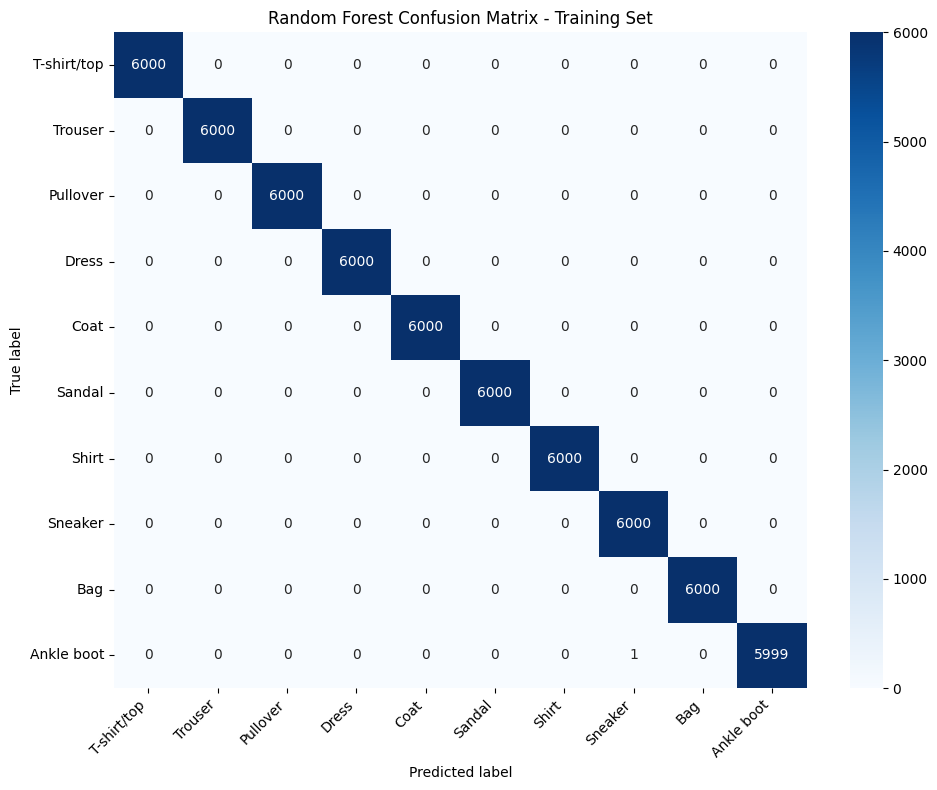

Saved figure: results/rf_train_confusion_matrix.png


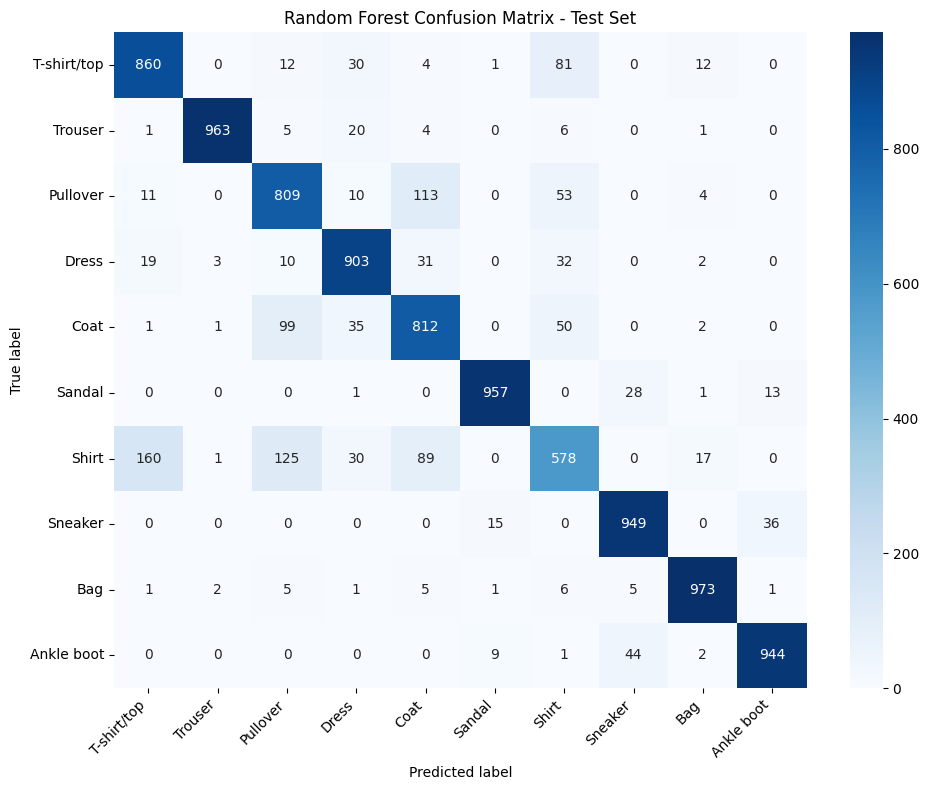

Saved figure: results/rf_test_confusion_matrix.png


In [21]:
# ============================================================
# Step 21: Plot and save Random Forest confusion matrices
# ============================================================

plot_confusion_matrix(
    rf_train_cm,
    "Random Forest Confusion Matrix - Training Set",
    "rf_train_confusion_matrix.png"
)

plot_confusion_matrix(
    rf_test_cm,
    "Random Forest Confusion Matrix - Test Set",
    "rf_test_confusion_matrix.png"
)

In [22]:
# ============================================================
# Step 22: Random Forest precision and recall for train and test sets
# ============================================================

rf_train_report = classification_report(
    y_train,
    rf_train_pred,
    target_names=class_names,
    output_dict=True
)

rf_test_report = classification_report(
    y_test,
    rf_test_pred,
    target_names=class_names,
    output_dict=True
)

rf_metrics_rows = []

for class_name in class_names:
    rf_metrics_rows.append({
        "Model": "Random Forest",
        "Dataset": "Training",
        "Class": class_name,
        "Precision": rf_train_report[class_name]["precision"],
        "Recall": rf_train_report[class_name]["recall"],
        "F1-score": rf_train_report[class_name]["f1-score"]
    })

for class_name in class_names:
    rf_metrics_rows.append({
        "Model": "Random Forest",
        "Dataset": "Test",
        "Class": class_name,
        "Precision": rf_test_report[class_name]["precision"],
        "Recall": rf_test_report[class_name]["recall"],
        "F1-score": rf_test_report[class_name]["f1-score"]
    })

rf_metrics_df = pd.DataFrame(rf_metrics_rows)

# Round values for easier reading
rf_metrics_df[["Precision", "Recall", "F1-score"]] = rf_metrics_df[
    ["Precision", "Recall", "F1-score"]
].round(4)

rf_metrics_df

,Model,Dataset,Class,Precision,Recall,F1-score
0,Random Forest,Training,T-shirt/top,1.0000,1.0000,1.0000
1,Random Forest,Training,Trouser,1.0000,1.0000,1.0000
2,Random Forest,Training,Pullover,1.0000,1.0000,1.0000
3,Random Forest,Training,Dress,1.0000,1.0000,1.0000
4,Random Forest,Training,Coat,1.0000,1.0000,1.0000
5,Random Forest,Training,Sandal,1.0000,1.0000,1.0000
6,Random Forest,Training,Shirt,1.0000,1.0000,1.0000
7,Random Forest,Training,Sneaker,0.9998,1.0000,0.9999
8,Random Forest,Training,Bag,1.0000,1.0000,1.0000
9,Random Forest,Training,Ankle boot,1.0000,0.9998,0.9999


In [23]:
# ============================================================
# Step 23: Save Random Forest metrics table
# ============================================================

rf_metrics_path = os.path.join(results_dir, "rf_precision_recall_table.csv")
rf_metrics_df.to_csv(rf_metrics_path, index=False)

print(f"Random Forest metrics table saved to: {rf_metrics_path}")

Random Forest metrics table saved to: results/rf_precision_recall_table.csv


In [24]:
# ============================================================
# Step 24: Create model comparison table
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["CNN", "Random Forest"],
    "Training Accuracy": [cnn_train_accuracy, rf_train_accuracy],
    "Test Accuracy": [cnn_test_accuracy, rf_test_accuracy],
    "Training Time (seconds)": [cnn_training_time, rf_training_time]
})

comparison_df["Training Accuracy"] = comparison_df["Training Accuracy"].round(4)
comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].round(4)
comparison_df["Training Time (seconds)"] = comparison_df["Training Time (seconds)"].round(2)

comparison_df

,Model,Training Accuracy,Test Accuracy,Training Time (seconds)
0,CNN,0.9357,0.9066,107.62
1,Random Forest,1.0000,0.8748,19.35


In [26]:
# ============================================================
# Step 25: Save model comparison table
# ============================================================

comparison_path = os.path.join(results_dir, "model_comparison_table.csv")
comparison_df.to_csv(comparison_path, index=False)

print(f"Model comparison table saved to: {comparison_path}")

Model comparison table saved to: results/model_comparison_table.csv


In [27]:
# ============================================================
# Step 26: Identify worst-performing classes using test recall
# ============================================================

cnn_test_metrics = cnn_metrics_df[cnn_metrics_df["Dataset"] == "Test"].copy()
rf_test_metrics = rf_metrics_df[rf_metrics_df["Dataset"] == "Test"].copy()

cnn_worst_classes = cnn_test_metrics.sort_values(by="Recall", ascending=True).head(3)
rf_worst_classes = rf_test_metrics.sort_values(by="Recall", ascending=True).head(3)

print("CNN worst-performing classes based on test recall:")
display(cnn_worst_classes[["Model", "Class", "Precision", "Recall", "F1-score"]])

print("Random Forest worst-performing classes based on test recall:")
display(rf_worst_classes[["Model", "Class", "Precision", "Recall", "F1-score"]])

CNN worst-performing classes based on test recall:


,Model,Class,Precision,Recall,F1-score
16,CNN,Shirt,0.6912,0.761,0.7244
12,CNN,Pullover,0.8981,0.820,0.8573
10,CNN,T-shirt/top,0.8474,0.855,0.8512


Random Forest worst-performing classes based on test recall:


,Model,Class,Precision,Recall,F1-score
16,Random Forest,Shirt,0.7162,0.578,0.6397
12,Random Forest,Pullover,0.7596,0.809,0.7835
14,Random Forest,Coat,0.7675,0.812,0.7891


In [28]:
# ============================================================
# Step 27: Save worst-performing class tables
# ============================================================

worst_classes_df = pd.concat([cnn_worst_classes, rf_worst_classes], axis=0)

worst_classes_path = os.path.join(results_dir, "worst_performing_classes.csv")
worst_classes_df.to_csv(worst_classes_path, index=False)

print(f"Worst-performing classes table saved to: {worst_classes_path}")

Worst-performing classes table saved to: results/worst_performing_classes.csv


## Analysis of Worst-Performing Categories

The worst-performing categories were identified using test-set recall, because recall indicates how many true examples of a class were correctly recognized by the model.

For the CNN model, the three weakest categories were Shirt, Pullover, and T-shirt/top. These categories are visually similar because they all represent upper-body garments with overlapping shapes, sleeve structures, and silhouettes. The Shirt class was the most difficult for the CNN, with a recall of 0.7610. This suggests that a considerable number of true Shirt images were misclassified as other visually related clothing categories.

For the Random Forest classifier, the three weakest categories were Shirt, Pullover, and Coat. The Shirt class was again the most problematic category, with a recall of 0.5780. This performance is substantially lower than the CNN result for the same class. A likely explanation is that Random Forest receives the image as a flattened vector of 784 pixel values and therefore does not explicitly learn spatial image patterns such as edges, local textures, and garment shape. In contrast, the CNN uses convolutional filters and pooling operations, which are more suitable for image-based feature extraction.

Overall, the error pattern shows that both classifiers perform better on visually distinctive categories such as footwear or bags, while they perform worse on clothing categories with similar outlines. This supports the recommendation that the CNN is more appropriate for production use in a fashion product classification system.

## Model Comparison and Production Recommendation

The CNN achieved stronger generalization performance than the Random Forest classifier. The Random Forest reached a training accuracy of 1.0000, but its test accuracy was lower, indicating that it memorized the training data more strongly than it generalized to unseen test images. This is a typical sign of overfitting.

The CNN required a longer training time than the Random Forest, but it achieved better test performance and handled image structure more effectively. This is because CNNs are specifically designed for image data: convolutional layers learn local spatial patterns such as edges, shapes, and textures, while pooling layers reduce spatial dimensions and support more robust feature extraction.

In contrast, the Random Forest model used flattened 28 × 28 images as 784 individual pixel features. This representation loses the two-dimensional spatial structure of the image. As a result, Random Forest is less suitable for distinguishing visually similar fashion categories, especially upper-body garments such as Shirt, Pullover, Coat, and T-shirt/top.

For production use in an automated fashion product classification system, the CNN is recommended. Although it requires more training time, it provides better test-set performance and is more appropriate for image classification. The Random Forest can still be useful as a baseline model because it is simpler and faster to train, but the CNN is the better final choice for deployment.

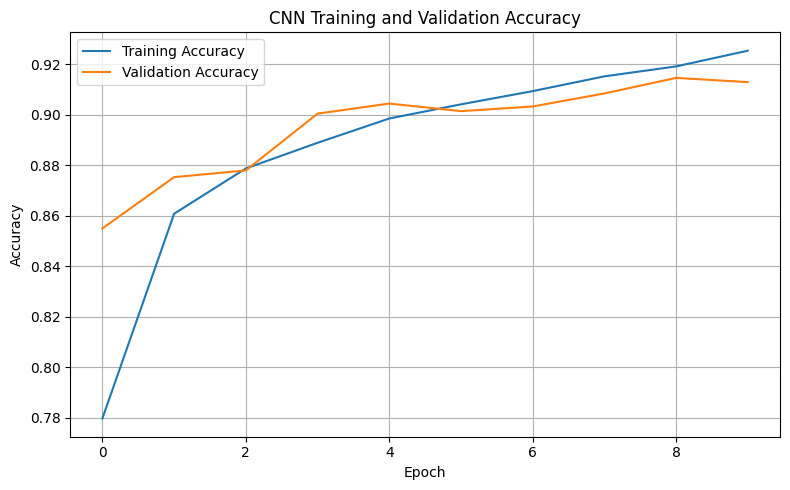

Saved accuracy plot: results/cnn_training_validation_accuracy.png


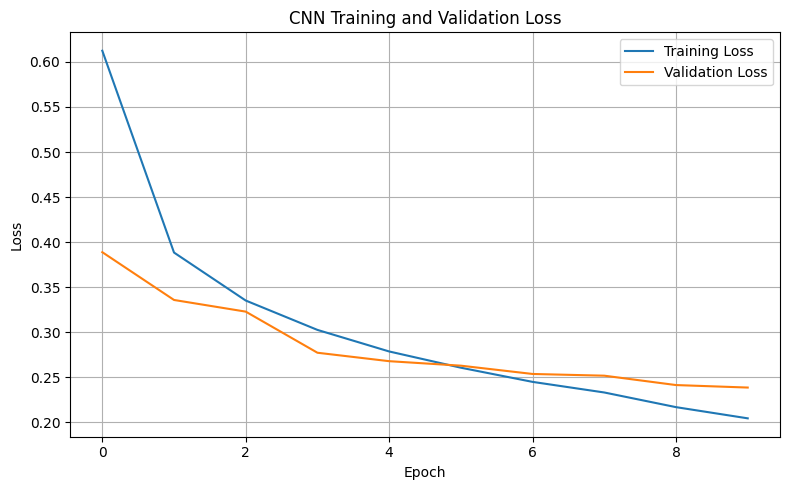

Saved loss plot: results/cnn_training_validation_loss.png


In [29]:
# ============================================================
# Step 31: Plot CNN training and validation accuracy/loss
# ============================================================

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_plot_path = os.path.join(results_dir, "cnn_training_validation_accuracy.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved accuracy plot: {accuracy_plot_path}")

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "cnn_training_validation_loss.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved loss plot: {loss_plot_path}")

In [30]:
# ============================================================
# Step 32: Final summary of main project results
# ============================================================

final_summary = pd.DataFrame({
    "Criterion": [
        "Training accuracy",
        "Test accuracy",
        "Training time (seconds)",
        "Worst test class by recall",
        "Recommended for production"
    ],
    "CNN": [
        round(cnn_train_accuracy, 4),
        round(cnn_test_accuracy, 4),
        round(cnn_training_time, 2),
        cnn_worst_classes.iloc[0]["Class"],
        "Yes"
    ],
    "Random Forest": [
        round(rf_train_accuracy, 4),
        round(rf_test_accuracy, 4),
        round(rf_training_time, 2),
        rf_worst_classes.iloc[0]["Class"],
        "No"
    ]
})

final_summary

,Criterion,CNN,Random Forest
0,Training accuracy,0.9357,1.0
1,Test accuracy,0.9066,0.8748
2,Training time (seconds),107.62,19.35
3,Worst test class by recall,Shirt,Shirt
4,Recommended for production,Yes,No


In [31]:
# ============================================================
# Step 33: Save final summary table
# ============================================================

final_summary_path = os.path.join(results_dir, "final_project_summary.csv")
final_summary.to_csv(final_summary_path, index=False)

print(f"Final summary table saved to: {final_summary_path}")

Final summary table saved to: results/final_project_summary.csv


## Conclusion

This project compared a Convolutional Neural Network and a Random Forest classifier for Fashion-MNIST product classification. Both models were trained and evaluated using the same training and test partitions of the dataset. The evaluation included training accuracy, test accuracy, training time, confusion matrices, and class-level precision and recall.

The results showed that the CNN achieved better generalization performance on the test set, while the Random Forest classifier reached perfect training accuracy but lower test accuracy. This indicates that the Random Forest model overfitted the training data more strongly. The weakest categories for both models were mainly visually similar upper-body garments, especially Shirt, Pullover, Coat, and T-shirt/top.

Based on the evaluation, the CNN is recommended for production use in a fashion retail image-classification scenario. Although it required more training time, it was better suited to image data because it learned spatial features directly from the 28 × 28 pixel images. The Random Forest classifier was useful as a baseline model, but it was less suitable as the final production model because it relied on flattened pixel vectors and did not preserve spatial image structure.